In [19]:
# ============================================================
# RAW SIGNAL VISUALIZATION - TRANSPARENT BACKGROUND
# Simple time-domain plot of vibration signal with no background
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# -------------------------
# CONFIGURATION
# -------------------------

# File path
FILE_PATH = r"F:\D8B2\N1440_1\Vib\20250211_112723_Vib.mat"

# Output directory
OUTPUT_DIR = r"E:\Conferences Umar\Conference 3\Results\Raw_Signal_Plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Sampling rate (you may need to adjust this)
FS = 25600  # Hz (typical for vibration signals, adjust if different)

print("="*80)
print("RAW SIGNAL VISUALIZATION - TRANSPARENT BACKGROUND")
print("="*80)

# -------------------------
# UTILITY FUNCTION
# -------------------------

def find_1d_signal_in_mat(mat_dict):
    """Extract 1D signal from .mat file"""
    candidates = []
    
    # First pass: look for 1D arrays
    for k, v in mat_dict.items():
        if k.startswith("__"):
            continue
        if isinstance(v, np.ndarray) and np.issubdtype(v.dtype, np.number):
            arr = np.array(v).squeeze()
            if arr.ndim == 1 and arr.size > 100:
                candidates.append((k, arr.size, arr))
                
    if not candidates:
        # Second pass: try to reshape any numeric array
        for k, v in mat_dict.items():
            if k.startswith("__"):
                continue
            if isinstance(v, np.ndarray) and np.issubdtype(v.dtype, np.number):
                arr = np.array(v).squeeze()
                if arr.size > 100:
                    return k, arr.reshape(-1).astype(np.float32)
        raise ValueError("No suitable numeric 1D signal found in .mat file.")
    
    # Return longest array
    candidates.sort(key=lambda x: x[1], reverse=True)
    return candidates[0][0], candidates[0][2].astype(np.float32)

# -------------------------
# LOAD SIGNAL
# -------------------------

print(f"\nLoading signal...")
print(f"  File: {os.path.basename(FILE_PATH)}")

try:
    mat_data = loadmat(FILE_PATH)
    var_name, signal = find_1d_signal_in_mat(mat_data)
    
    print(f"  Variable name: {var_name}")
    print(f"  Signal length: {len(signal)} samples")
    print(f"  Duration: {len(signal)/FS:.2f} seconds (assuming Fs={FS} Hz)")
    print(f"  Amplitude range: [{signal.min():.4f}, {signal.max():.4f}]")
    
except Exception as e:
    print(f"\n❌ Error loading file: {e}")
    
    # Try to see what's in the file
    print("\nAttempting to inspect file contents...")
    mat_data = loadmat(FILE_PATH)
    print("\nVariables in .mat file:")
    for key in mat_data.keys():
        if not key.startswith('__'):
            val = mat_data[key]
            print(f"  {key}: {type(val)}, shape={getattr(val, 'shape', 'N/A')}, dtype={getattr(val, 'dtype', 'N/A')}")
    exit()

# -------------------------
# GENERATE TIME VECTOR
# -------------------------

time_seconds = np.arange(len(signal)) / FS

# -------------------------
# PLOT 1: FULL SIGNAL (TRANSPARENT)
# -------------------------

print(f"\n1. Plotting full signal (transparent)...")

fig, ax = plt.subplots(figsize=(16, 6), facecolor='none')
ax.patch.set_alpha(0)

ax.plot(time_seconds, signal, linewidth=1, color='#1f77b4', alpha=0.8)

ax.set_xlabel('Time (s)', fontsize=18, fontweight='bold', color='black')
ax.set_ylabel('Amplitude', fontsize=18, fontweight='bold', color='black')
ax.set_title(f'Raw Vibration Signal - {os.path.basename(FILE_PATH)}', 
            fontsize=18, fontweight='bold', pad=15, color='black')
ax.grid(alpha=0.3, linestyle='--', linewidth=0.8, color='gray')
ax.tick_params(axis='both', labelsize=14, width=1.5, colors='black')

# Make spines visible
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_color('black')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "raw_signal_full_transparent.png"), 
           dpi=1000, bbox_inches='tight', transparent=True)
plt.close()

print(f"  ✓ Saved: raw_signal_full_transparent.png")

# -------------------------
# PLOT 2: ZOOMED VIEW (First 1 second) - TRANSPARENT
# -------------------------

print(f"\n2. Plotting zoomed view (first 1 second, transparent)...")

zoom_duration = 1.0  # seconds
n_samples_zoom = int(zoom_duration * FS)
n_samples_zoom = min(n_samples_zoom, len(signal))

signal_zoom = signal[:n_samples_zoom]
time_zoom = time_seconds[:n_samples_zoom]

fig, ax = plt.subplots(figsize=(16, 6), facecolor='none')
ax.patch.set_alpha(0)

ax.plot(time_zoom, signal_zoom, linewidth=1.0, color='#1f77b4', alpha=0.9)

ax.set_xlabel('Time (s)', fontsize=18, fontweight='bold', color='black')
ax.set_ylabel('Amplitude', fontsize=18, fontweight='bold', color='black')
ax.set_title(f'Raw Vibration Signal - Zoomed (First {zoom_duration} second)', 
            fontsize=18, fontweight='bold', pad=15, color='black')
ax.grid(alpha=0.3, linestyle='--', linewidth=0.8, color='gray')
ax.tick_params(axis='both', labelsize=14, width=1.5, colors='black')
ax.set_xlim([0, zoom_duration])

# Make spines visible
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_color('black')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "raw_signal_zoom_1sec_transparent.png"), 
           dpi=1000, bbox_inches='tight', transparent=True)
plt.close()

print(f"  ✓ Saved: raw_signal_zoom_1sec_transparent.png")

# -------------------------
# PLOT 3: EXTREME ZOOM (First 0.1 seconds) - TRANSPARENT
# -------------------------

print(f"\n3. Plotting extreme zoom (first 0.1 seconds, transparent)...")

extreme_zoom_duration = 0.1  # seconds
n_samples_extreme = int(extreme_zoom_duration * FS)
n_samples_extreme = min(n_samples_extreme, len(signal))

signal_extreme = signal[:n_samples_extreme]
time_extreme = time_seconds[:n_samples_extreme]

fig, ax = plt.subplots(figsize=(16, 6), facecolor='none')
ax.patch.set_alpha(0)

ax.plot(time_extreme, signal_extreme, linewidth=1.2, color='#1f77b4', alpha=0.9)

ax.set_xlabel('Time (s)', fontsize=18, fontweight='bold', color='black')
ax.set_ylabel('Amplitude', fontsize=18, fontweight='bold', color='black')
ax.set_title(f'Raw Vibration Signal - Extreme Zoom (First {extreme_zoom_duration} second)', 
            fontsize=18, fontweight='bold', pad=15, color='black')
ax.grid(alpha=0.3, linestyle='--', linewidth=0.8, color='gray')
ax.tick_params(axis='both', labelsize=14, width=1.5, colors='black')
ax.set_xlim([0, extreme_zoom_duration])

# Make spines visible
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_color('black')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "raw_signal_zoom_0.1sec_transparent.png"), 
           dpi=1000, bbox_inches='tight', transparent=True)
plt.close()

print(f"  ✓ Saved: raw_signal_zoom_0.1sec_transparent.png")

# -------------------------
# PLOT 4: STATISTICS BOX - TRANSPARENT
# -------------------------

print(f"\n4. Generating signal statistics (transparent)...")

fig, ax = plt.subplots(figsize=(16, 7), facecolor='none')
ax.patch.set_alpha(0)

ax.plot(time_seconds, signal, linewidth=0.6, color='#1f77b4', alpha=0.8)

# Calculate statistics
signal_mean = np.mean(signal)
signal_std = np.std(signal)
signal_rms = np.sqrt(np.mean(signal**2))
signal_peak = np.max(np.abs(signal))
signal_crest = signal_peak / signal_rms if signal_rms > 0 else 0

# Add statistics box with semi-transparent background
stats_text = f"""Signal Statistics:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Mean:        {signal_mean:.6f}
Std Dev:     {signal_std:.6f}
RMS:         {signal_rms:.6f}
Peak:        {signal_peak:.6f}
Crest Factor: {signal_crest:.2f}
Duration:     {len(signal)/FS:.2f} s
Samples:      {len(signal)}
Sample Rate:  {FS} Hz"""

ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
       fontsize=11, verticalalignment='top', color='black',
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
       family='monospace', fontweight='bold')

ax.set_xlabel('Time (s)', fontsize=18, fontweight='bold', color='black')
ax.set_ylabel('Amplitude', fontsize=18, fontweight='bold', color='black')
ax.set_title(f'Raw Vibration Signal with Statistics', 
            fontsize=18, fontweight='bold', pad=15, color='black')
ax.grid(alpha=0.3, linestyle='--', linewidth=0.8, color='gray')
ax.tick_params(axis='both', labelsize=14, width=1.5, colors='black')

# Make spines visible
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_color('black')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "raw_signal_with_stats_transparent.png"), 
           dpi=1000, bbox_inches='tight', transparent=True)
plt.close()

print(f"  ✓ Saved: raw_signal_with_stats_transparent.png")

# -------------------------
# PLOT 5: NO GRID, NO TITLE - MINIMAL (TRANSPARENT)
# -------------------------

print(f"\n5. Generating minimal plot (no grid, no title, transparent)...")

fig, ax = plt.subplots(figsize=(16, 6), facecolor='none')
ax.patch.set_alpha(0)

ax.plot(time_seconds, signal, linewidth=0.8, color='#1f77b4', alpha=0.9)

ax.set_xlabel('Time (s)', fontsize=18, fontweight='bold', color='black')
ax.set_ylabel('Amplitude', fontsize=18, fontweight='bold', color='black')
ax.tick_params(axis='both', labelsize=14, width=1.5, colors='black')

# Make spines visible
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_color('black')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "raw_signal_minimal_transparent.png"), 
           dpi=1000, bbox_inches='tight', transparent=True)
plt.close()

print(f"  ✓ Saved: raw_signal_minimal_transparent.png")

# -------------------------
# PLOT 6: ONLY SIGNAL LINE - ULTRA MINIMAL (TRANSPARENT)
# -------------------------

print(f"\n6. Generating ultra minimal plot (only signal, transparent)...")

fig, ax = plt.subplots(figsize=(16, 6), facecolor='none')
ax.patch.set_alpha(0)

ax.plot(time_seconds, signal, linewidth=0.8, color='#1f77b4', alpha=0.9)

# Remove all spines, ticks, labels
ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "raw_signal_ultra_minimal_transparent.png"), 
           dpi=1000, bbox_inches='tight', transparent=True, pad_inches=0)
plt.close()

print(f"  ✓ Saved: raw_signal_ultra_minimal_transparent.png")

# -------------------------
# SUMMARY
# -------------------------

print("\n" + "="*80)
print("✅ RAW SIGNAL PLOTS COMPLETE!")
print("="*80)
print(f"\nGenerated 6 plots (all with transparent background):")
print(f"  1. raw_signal_full_transparent.png          - Complete signal")
print(f"  2. raw_signal_zoom_1sec_transparent.png     - First 1 second")
print(f"  3. raw_signal_zoom_0.1sec_transparent.png   - First 0.1 seconds")
print(f"  4. raw_signal_with_stats_transparent.png    - With statistics box")
print(f"  5. raw_signal_minimal_transparent.png       - No grid, no title")
print(f"  6. raw_signal_ultra_minimal_transparent.png - Only signal line")
print(f"\nAll saved to: {OUTPUT_DIR}")
print(f"Resolution: 1000 DPI, transparent background")
print(f"Perfect for overlaying on presentations/papers!")
print("="*80)

RAW SIGNAL VISUALIZATION - TRANSPARENT BACKGROUND

Loading signal...
  File: 20250211_112723_Vib.mat
  Variable name: signals
  Signal length: 51200 samples
  Duration: 2.00 seconds (assuming Fs=25600 Hz)
  Amplitude range: [-3.8677, 4.0148]

1. Plotting full signal (transparent)...
  ✓ Saved: raw_signal_full_transparent.png

2. Plotting zoomed view (first 1 second, transparent)...
  ✓ Saved: raw_signal_zoom_1sec_transparent.png

3. Plotting extreme zoom (first 0.1 seconds, transparent)...
  ✓ Saved: raw_signal_zoom_0.1sec_transparent.png

4. Generating signal statistics (transparent)...
  ✓ Saved: raw_signal_with_stats_transparent.png

5. Generating minimal plot (no grid, no title, transparent)...
  ✓ Saved: raw_signal_minimal_transparent.png

6. Generating ultra minimal plot (only signal, transparent)...
  ✓ Saved: raw_signal_ultra_minimal_transparent.png

✅ RAW SIGNAL PLOTS COMPLETE!

Generated 6 plots (all with transparent background):
  1. raw_signal_full_transparent.png          

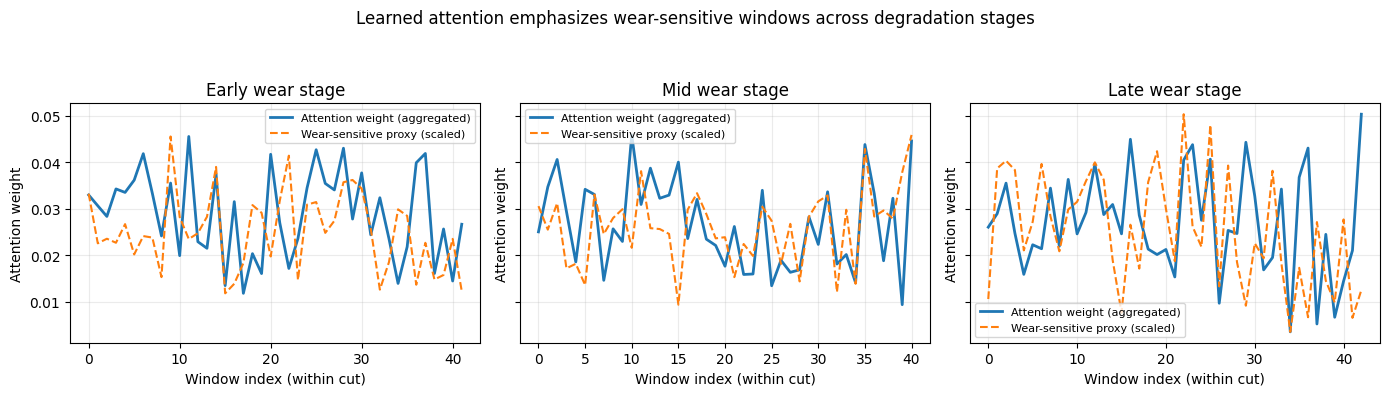

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def plot_attention_stages(alpha_by_cut, proxy_by_cut=None,
                          stage_names=("Early", "Mid", "Late"),
                          stage_cut_indices=None,
                          n_cuts_per_stage=3,
                          aggregate="mean",
                          title="Attention weights across windows (early/mid/late wear)"):
    """
    alpha_by_cut: list of 1D arrays (length N_k) attention weights per cut k
                  OR 2D object array where each row is variable-length.
    proxy_by_cut: (optional) list of 1D arrays (same length as alpha_by_cut[k])
                  e.g., AE_RMS per window, signal energy, etc.
    stage_cut_indices: dict like {"Early":[0,1,2], "Mid":[50,51,52], "Late":[100,101,102]}
                       If None, stages are selected uniformly from the timeline.
    aggregate: "mean" or "median" across selected cuts per stage (after length alignment).
    """

    # Convert to list of np arrays
    alpha_list = [np.asarray(a).astype(float).ravel() for a in alpha_by_cut]
    if proxy_by_cut is not None:
        proxy_list = [np.asarray(p).astype(float).ravel() for p in proxy_by_cut]
        assert len(proxy_list) == len(alpha_list), "proxy_by_cut must match alpha_by_cut length"
    else:
        proxy_list = None

    K = len(alpha_list)
    if K < 3:
        raise ValueError("Need attention for at least 3 cuts to show early/mid/late.")

    # Default stage selection if not provided
    if stage_cut_indices is None:
        # pick cuts from first 20%, middle around 50%, last 20%
        def pick_indices(start, end, n):
            idx = np.linspace(start, end, num=n, dtype=int)
            idx = np.clip(idx, 0, K-1)
            return sorted(set(idx.tolist()))

        early = pick_indices(0, max(0, int(0.2*(K-1))), n_cuts_per_stage)
        mid_center = int(0.5*(K-1))
        mid = pick_indices(max(0, mid_center - int(0.05*K)), min(K-1, mid_center + int(0.05*K)), n_cuts_per_stage)
        late = pick_indices(min(K-1, int(0.8*(K-1))), K-1, n_cuts_per_stage)

        stage_cut_indices = {stage_names[0]: early, stage_names[1]: mid, stage_names[2]: late}

    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
    fig.suptitle(title)

    for ax, sname in zip(axes, stage_names):
        idxs = stage_cut_indices.get(sname, [])
        if len(idxs) == 0:
            raise ValueError(f"No cut indices provided for stage '{sname}'.")

        # Align variable-length windows by padding with NaN to max length in this stage
        max_len = max(len(alpha_list[k]) for k in idxs)
        A = np.full((len(idxs), max_len), np.nan, dtype=float)

        P = None
        if proxy_list is not None:
            P = np.full((len(idxs), max_len), np.nan, dtype=float)

        for r, k in enumerate(idxs):
            a = alpha_list[k]
            A[r, :len(a)] = a
            if proxy_list is not None:
                p = proxy_list[k]
                if len(p) != len(a):
                    raise ValueError(f"Proxy length mismatch at cut {k}: {len(p)} vs alpha {len(a)}")
                P[r, :len(p)] = p

        # Aggregate across cuts
        if aggregate == "median":
            a_agg = np.nanmedian(A, axis=0)
            if P is not None:
                p_agg = np.nanmedian(P, axis=0)
        else:
            a_agg = np.nanmean(A, axis=0)
            if P is not None:
                p_agg = np.nanmean(P, axis=0)

        x = np.arange(len(a_agg))

        ax.plot(x, a_agg, linewidth=2, label="Attention weight (aggregated)")
        ax.set_title(f"{sname} wear stage")
        ax.set_xlabel("Window index (within cut)")
        ax.set_ylabel("Attention weight")

        # Optional proxy overlay (scaled to match)
        if P is not None:
            # Normalize proxy to [0,1] then scale to attention range for overlay
            p = p_agg.copy()
            p = p - np.nanmin(p)
            denom = np.nanmax(p) if np.nanmax(p) > 0 else 1.0
            p = p / denom

            # Scale proxy to attention axis range
            a_min, a_max = np.nanmin(a_agg), np.nanmax(a_agg)
            p_scaled = a_min + p * (a_max - a_min)

            ax.plot(x, p_scaled, linestyle="--", linewidth=1.5, label="Wear-sensitive proxy (scaled)")

        # Minor cosmetics
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8, loc="best")

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()


# -----------------------------
# EXAMPLE USAGE (replace with your actual arrays)
# -----------------------------
if __name__ == "__main__":
    # Example: list of variable-length attention arrays for each cut
    # Replace these with real outputs saved from your model
    rng = np.random.default_rng(0)
    alpha_by_cut = []
    proxy_by_cut = []
    K = 120
    for k in range(K):
        Nk = rng.integers(25, 45)  # windows per cut
        raw = rng.random(Nk)
        alpha = raw / raw.sum()    # softmax-like normalized weights
        alpha_by_cut.append(alpha)

        # proxy: e.g., AE RMS increases with wear (toy example)
        proxy = (0.2 + 0.8*(k/(K-1))) * (rng.random(Nk) + 0.5)
        proxy_by_cut.append(proxy)

    plot_attention_stages(
        alpha_by_cut=alpha_by_cut,
        proxy_by_cut=proxy_by_cut,
        title="Learned attention emphasizes wear-sensitive windows across degradation stages"
    )


C:\Users\Muhammad Umar\AppData\Local\Temp\ipykernel_30248\249976637.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(stage_data, labels=labels, showfliers=False)


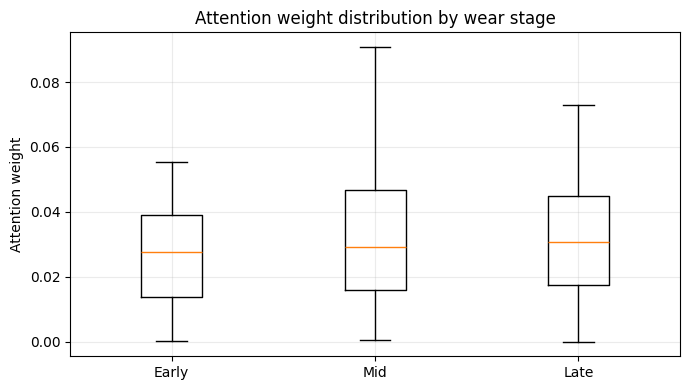

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def plot_attention_distribution(alpha_by_cut, stage_cut_indices, title="Attention weight distribution by wear stage"):
    alpha_list = [np.asarray(a).astype(float).ravel() for a in alpha_by_cut]

    stage_data = []
    labels = []
    for stage, idxs in stage_cut_indices.items():
        vals = np.concatenate([alpha_list[k] for k in idxs])
        stage_data.append(vals)
        labels.append(stage)

    plt.figure(figsize=(7, 4))
    plt.boxplot(stage_data, labels=labels, showfliers=False)
    plt.ylabel("Attention weight")
    plt.title(title)
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


# Example
if __name__ == "__main__":
    rng = np.random.default_rng(0)
    K = 120
    alpha_by_cut = []
    for k in range(K):
        Nk = rng.integers(25, 45)
        raw = rng.random(Nk)
        alpha_by_cut.append(raw / raw.sum())

    stage_cut_indices = {
        "Early": list(range(0, 5)),
        "Mid": list(range(55, 60)),
        "Late": list(range(115, 120)),
    }

    plot_attention_distribution(alpha_by_cut, stage_cut_indices)
